In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ieeg.auth import Session
from scipy import signal
import mne
import json
import pandas as pd
import os
import re
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from multiprocessing import Pool
import scipy.stats as stats
import ast

# Import custom functions
import sys, os
code_v3_path = os.path.dirname('/mnt/leif/littlab/users/aguilac/Interictal_Spike_Analysis/HUMAN/spike_detector/')
sys.path.append(code_v3_path)
from spike_detector import *
from iEEG_helper_functions import *
from spike_morphology_v2 import *

code_path = os.path.dirname('/mnt/leif/littlab/users/aguilac/Interictal_Spike_Analysis/HUMAN/working_feat_extract_code/functions/')
sys.path.append(code_path)
from ied_fx_v3 import *

import sys, os
code_v2_path = os.path.dirname('../Ei/')
sys.path.append(code_v2_path)
from utils import get_iEEG_data, notch_filter

In [2]:
#Load in the datasets

# HFER (200s)
# hup_ei = pd.read_csv('../data/self_run/HUP_all_hfer.csv')

#EI
hup_ei = pd.read_csv('../data/self_run/EI_HUP_60s.csv')

#hfer NEW (60s)
# hup_ei = pd.read_csv('../data/self_run/hfer_HUP_60s.csv')

#HFER 21seconds (1 before, 20 after labeled onset)
# hup_ei = pd.read_csv('../data/self_run/hfer_HUP_21s.csv')

#HFER increase and push back the baseline a little bit
# hup_ei = pd.read_csv('../data/self_run/HUP_HFER_baseline_pushedback.csv') #DID NOT WORK


First let's look at HUP204's first seizure.

This is a classic MTLE seizure.

Onset time: 29755.28 seconds


In [3]:
#Load the seizure.

start_time = 29755.28 #in seconds 
start_usec = start_time * 1e6
stop_time = 29860.28 #in seconds
stop_usec = stop_time * 1e6

dataset_name = 'HUP204_phaseII' #dataset name that we want to look at

pw_path = '/mnt/leif/littlab/users/aguilac/tools/agu_ieeglogin.bin'
with open(pw_path, 'r') as f:
    session = Session('aguilac', f.read().strip())

dataset = session.open_dataset(dataset_name)
all_channel_labels = np.array(dataset.get_channel_labels())
channel_labels_to_download = all_channel_labels[
    electrode_selection(all_channel_labels)
]
if channel_labels_to_download.size > 0:
    duration_usec = dataset.get_time_series_details(
        channel_labels_to_download[0]
    ).duration
    duration_secs = duration_usec / 1e6

# get iEEG_data
df, fs = get_iEEG_data(
    username='aguilac',
    password_bin_file = pw_path,
    iEEG_filename=dataset_name,
    start_time_usec=start_usec,
    stop_time_usec=stop_usec,
    select_electrodes = channel_labels_to_download,
)

# Apply notch filters at 60 Hz and harmonics
data = notch_filter(df.to_numpy(), fs) # Change to Bandstop or remove the Phase and Amplitude of 60z & Harms

if fs > 500:
    # Downsample
    target_fs = 500  # Target sampling frequency
    fs = int(fs)
    # Calculate the resampling factors
    gcd = np.gcd(fs, target_fs)
    up = target_fs // gcd
    down = fs // gcd
    # Resample each channel using polynomial interpolation
    downsampled_data = signal.resample_poly(data, up, down, axis=0)
    # Convert the downsampled numpy array back to a DataFrame
    df_downsampled = pd.DataFrame(downsampled_data, columns=[decompose_labels(x, 'HUP204') for x in df.columns])
    # New sampling frequency
    fs = target_fs
    data = df_downsampled


In [4]:
#find the specific row in hup_ei for this seizure.

hupID = 'HUP204'
start_time = 29755.28 #in seconds 
sz_204 = hup_ei[(hup_ei['hupID'] == hupID) & (hup_ei['ictal_start_time'] == start_time)]


#now fix the DF, so that we can look at the EI/channel
# remove any row that has all 0's for EI# Assuming 'df' is your DataFrame
sz_204['EI'] = sz_204['EI'].apply(lambda x: list(map(float, x.strip('[]').split())))

# Function to convert string representation of list to actual list
def convert_to_list(string_list):
    return ast.literal_eval(string_list)
# Apply the function to the 'name' column
sz_204['name'] = sz_204['name'].apply(convert_to_list)

# Remove rows where 'EI' is a list of all zeros
df_filtered = sz_204[sz_204['EI'].apply(lambda x: not np.all(np.array(x) == 0.0))]

##############
#HERE WE WILL ADD THE NORMALIZATION ACROSS EACH SEIZURE (PER ROW)
def z_score(values):
    mean = sum(values) / len(values)
    std_dev = (sum((x - mean) ** 2 for x in values) / len(values)) ** 0.5
    z_scores = [(x - mean) / std_dev for x in values]
    return z_scores

# df_filtered['EI'] = df_filtered['EI'].apply(z_score)
##############

# Explode the EI and name columns to unnest the lists
df_exploded = df_filtered.explode(['EI', 'name']).drop(columns = ['removed_channels'])

# Reset index if needed
df_exploded = df_exploded.reset_index(drop=True)

df_exploded['name'] = df_exploded['name'].str.replace("'", "", regex=False)

grouped = df_exploded.rename(columns={
    'hupID': 'pt_id',
    'name': 'channel_label',
    'EI': 'EI'  # EI remains the same, but included for clarity
})

grouped['channel_label'] = grouped.apply(
    lambda row: decompose_labels(row['channel_label'], row['pt_id']),
    axis=1
)

chs_tokeep = ['RA','LA','RDA','LDA','LH','RH','LDH','RDH','DA','DH','DHA','LB','LDB','LC','LDC','RB','RDB','RC','RDC']

#if channel_label contains any of the strings in chs_tokeep, keep it
all_spikes = grouped[grouped['channel_label'].str.contains('|'.join(chs_tokeep))].reset_index(drop=True)

all_spikes = all_spikes[~all_spikes['channel_label'].str.contains('T|F|P|RCC|RCA|RAD|LAD|LHD|RHD|LDAH|RDAH|RCB|Z')].reset_index(drop=True)

In [5]:
#lets plot the seizure for the channels we want
channels_to_keep = all_spikes['channel_label'].unique().tolist()
filtered_data = data[channels_to_keep]

#Lets sort this properly to get a sample seizure clip
# la_columns = [col for col in filtered_data.columns if col.startswith('LB')]
# sorted_la_columns = ['LA1','LA2','LA3','LA4','LA5','LA6','LA7','LA8','LA9','LA11','LA12']
sorted_lb_columns = ['LB12','LB11','LB9','LB8','LB7','LB6','LB5','LB4','LB3','LB2','LB1']  
la_data = filtered_data[sorted_lb_columns]


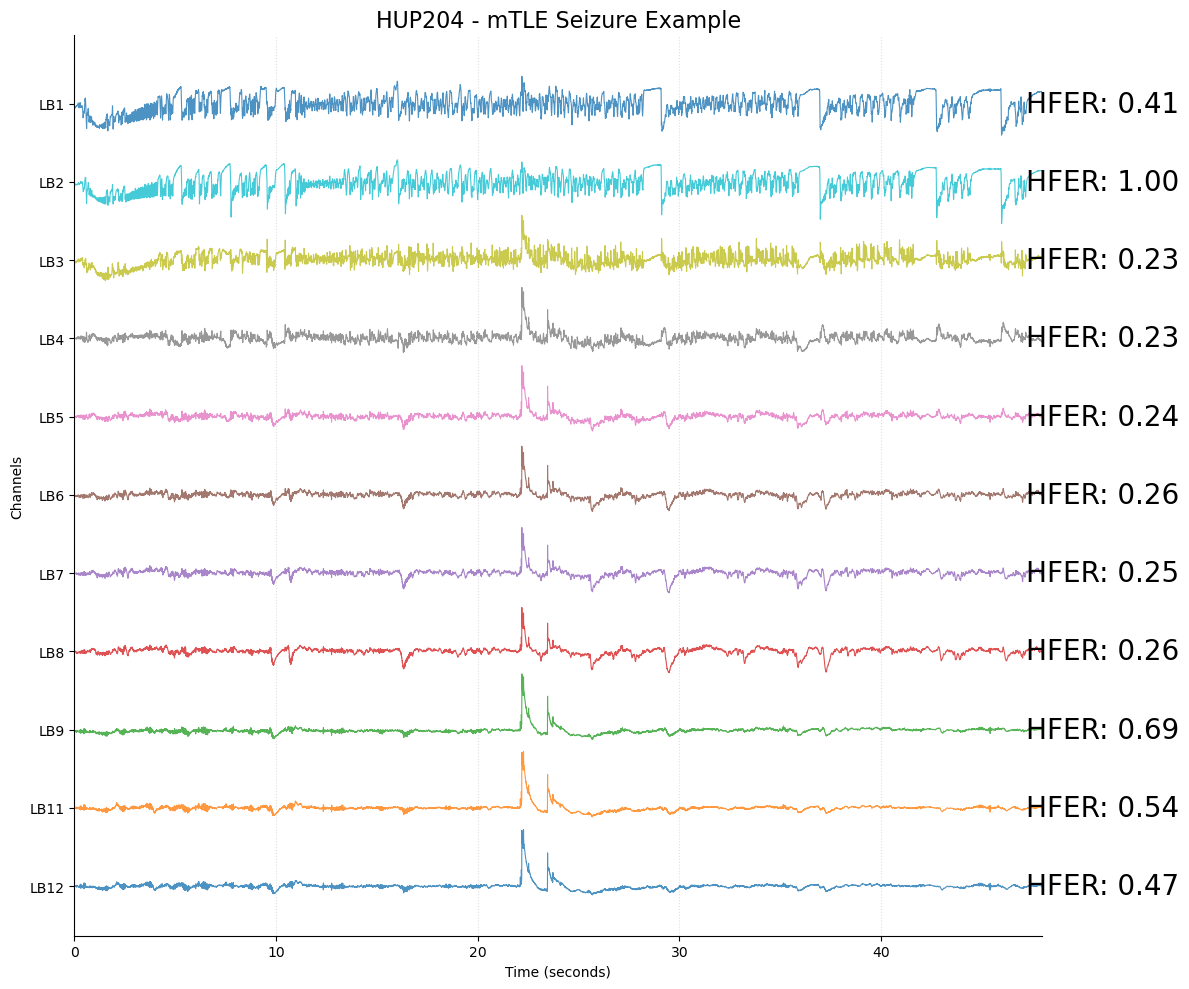

In [7]:
def plot_eeg_channels_with_hfer(data, all_spikes, sampling_rate=500, stop_time=None, title = 'Seizure Example'):
    # Create a time array
    time = np.arange(0, len(data)) / sampling_rate
    
    # Set up the plot
    plt.figure(figsize=(12, 10))
    plt.title(title, fontsize=16)
    
    # Define channel order
    # sorted_la_columns = ['LA12','LA11','LA9','LA8','LA7','LA6','LA5','LA4','LA3','LA2','LA1']
    sorted_lb_columns = ['LB12','LB11','LB9','LB8','LB7','LB6','LB5','LB4','LB3','LB2','LB1']  

    sorted_la_columns = sorted_lb_columns
    
    # Calculate offset and scaling factor for better visibility
    channel_range = {ch: (data[ch].max() - data[ch].min()) for ch in sorted_la_columns}
    max_range = max(channel_range.values())
    scaling_factor = 1.5
    offset = max_range * scaling_factor * 1.2
    
    # Set x-axis limits
    if stop_time is None:
        stop_time = max(time)
    plt.xlim(0, stop_time)
    
    # Extend the x-axis to accommodate HFER values
    x_extension_factor = 1.2  # Adjust this value to move text more to the right
    plt.xlim(0, stop_time * x_extension_factor)
    
    # Plot each channel
    for i, channel in enumerate(sorted_la_columns):
        # Center and scale the data for each channel
        centered_data = data[channel] - data[channel].mean()
        scaled_data = (centered_data / channel_range[channel]) * (max_range * scaling_factor)
        
        plt.plot(time, scaled_data + i*offset, linewidth=0.8, alpha=0.8)
        
        # Add HFER value as text
        hfer_value = all_spikes[all_spikes['channel_label'] == channel]['EI'].values
        if len(hfer_value) > 0:
            hfer_text = f"HFER: {hfer_value[0]:.2f}"
            plt.text(stop_time * (x_extension_factor - 0.02), i*offset, hfer_text, 
                     verticalalignment='center', horizontalalignment='left', fontsize=20)
    
    # Set y-ticks and labels to channel names
    plt.yticks(np.arange(len(sorted_la_columns)) * offset, sorted_la_columns)
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Channels')
    
    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    # Add minor gridlines for better time reference
    plt.grid(True, which='both', axis='x', linestyle=':', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

# Assuming your dataframe with LA channels is named 'la_data'
# and your all_spikes dataframe is named 'all_spikes'
# Call the function to plot
plot_eeg_channels_with_hfer(la_data, all_spikes, stop_time=40, title = 'HUP204 - mTLE Seizure Example')

First let's look at HUP209's second seizure.

This is a classic TNC seizure.

Onset time: 236351.47 seconds


In [8]:
start_time = 236351.47 #in seconds 
start_usec = start_time * 1e6
stop_time = 236487.36 #in seconds
stop_usec = stop_time * 1e6

dataset_name = 'HUP209_phaseII_D01' #dataset name that we want to look at

pw_path = '/mnt/leif/littlab/users/aguilac/tools/agu_ieeglogin.bin'
with open(pw_path, 'r') as f:
    session = Session('aguilac', f.read().strip())

dataset = session.open_dataset(dataset_name)
all_channel_labels = np.array(dataset.get_channel_labels())
channel_labels_to_download = all_channel_labels[
    electrode_selection(all_channel_labels)
]
if channel_labels_to_download.size > 0:
    duration_usec = dataset.get_time_series_details(
        channel_labels_to_download[0]
    ).duration
    duration_secs = duration_usec / 1e6

# get iEEG_data
df, fs = get_iEEG_data(
    username='aguilac',
    password_bin_file = pw_path,
    iEEG_filename=dataset_name,
    start_time_usec=start_usec,
    stop_time_usec=stop_usec,
    select_electrodes = channel_labels_to_download,
)

# Apply notch filters at 60 Hz and harmonics
data = notch_filter(df.to_numpy(), fs) # Change to Bandstop or remove the Phase and Amplitude of 60z & Harms

if fs > 500:
    # Downsample
    target_fs = 500  # Target sampling frequency
    fs = int(fs)
    # Calculate the resampling factors
    gcd = np.gcd(fs, target_fs)
    up = target_fs // gcd
    down = fs // gcd
    # Resample each channel using polynomial interpolation
    downsampled_data = signal.resample_poly(data, up, down, axis=0)
    # Convert the downsampled numpy array back to a DataFrame
    df_downsampled = pd.DataFrame(downsampled_data, columns=[decompose_labels(x, 'HUP204') for x in df.columns])
    # New sampling frequency
    fs = target_fs
    data = df_downsampled


In [9]:
#find the specific row in hup_ei for this seizure.

hupID = 'HUP209'
start_time = 236351.47 #in seconds 
sz_204 = hup_ei[(hup_ei['hupID'] == hupID)]# & (hup_ei['ictal_start_time'] == start_time)]

#now fix the DF, so that we can look at the EI/channel
# remove any row that has all 0's for EI# Assuming 'df' is your DataFrame
sz_204['EI'] = sz_204['EI'].apply(lambda x: list(map(float, x.strip('[]').split())))

# Function to convert string representation of list to actual list
def convert_to_list(string_list):
    return ast.literal_eval(string_list)
# Apply the function to the 'name' column
sz_204['name'] = sz_204['name'].apply(convert_to_list)

# Remove rows where 'EI' is a list of all zeros
df_filtered = sz_204[sz_204['EI'].apply(lambda x: not np.all(np.array(x) == 0.0))]

##############
#HERE WE WILL ADD THE NORMALIZATION ACROSS EACH SEIZURE (PER ROW)
def z_score(values):
    mean = sum(values) / len(values)
    std_dev = (sum((x - mean) ** 2 for x in values) / len(values)) ** 0.5
    z_scores = [(x - mean) / std_dev for x in values]
    return z_scores

# df_filtered['EI'] = df_filtered['EI'].apply(z_score)
##############

# Explode the EI and name columns to unnest the lists
df_exploded = df_filtered.explode(['EI', 'name']).drop(columns = ['removed_channels'])

# Reset index if needed
df_exploded = df_exploded.reset_index(drop=True)

df_exploded['name'] = df_exploded['name'].str.replace("'", "", regex=False)

grouped = df_exploded.rename(columns={
    'hupID': 'pt_id',
    'name': 'channel_label',
    'EI': 'EI'  # EI remains the same, but included for clarity
})

grouped['channel_label'] = grouped.apply(
    lambda row: decompose_labels(row['channel_label'], row['pt_id']),
    axis=1
)

chs_tokeep = ['RA','LA','RDA','LDA','LH','RH','LDH','RDH','DA','DH','DHA','LB','LDB','LC','LDC','RB','RDB','RC','RDC']

#if channel_label contains any of the strings in chs_tokeep, keep it
all_spikes = grouped[grouped['channel_label'].str.contains('|'.join(chs_tokeep))].reset_index(drop=True)

all_spikes = all_spikes[~all_spikes['channel_label'].str.contains('T|F|P|RCC|RCA|RAD|LAD|LHD|RHD|LDAH|RDAH|RCB|Z')].reset_index(drop=True)

In [18]:
#lets plot the seizure for the channels we want
channels_to_keep = all_spikes['channel_label'].unique().tolist()
filtered_data = data[channels_to_keep]

#Lets sort this properly to get a sample seizure clip
la_columns = [col for col in filtered_data.columns if col.startswith('LB')]
sorted_la_columns = ['LA1','LA2','LA3','LA4','LA5','LA6','LA7','LA8','LA9','LA11','LA12']
sorted_lb_columns = ['LB1','LB2','LB3','LB4','LB5','LB6','LB7','LB8','LB9','LB11','LB12','LH1']
la_data = filtered_data[sorted_la_columns]
lb_data = filtered_data[sorted_lb_columns]

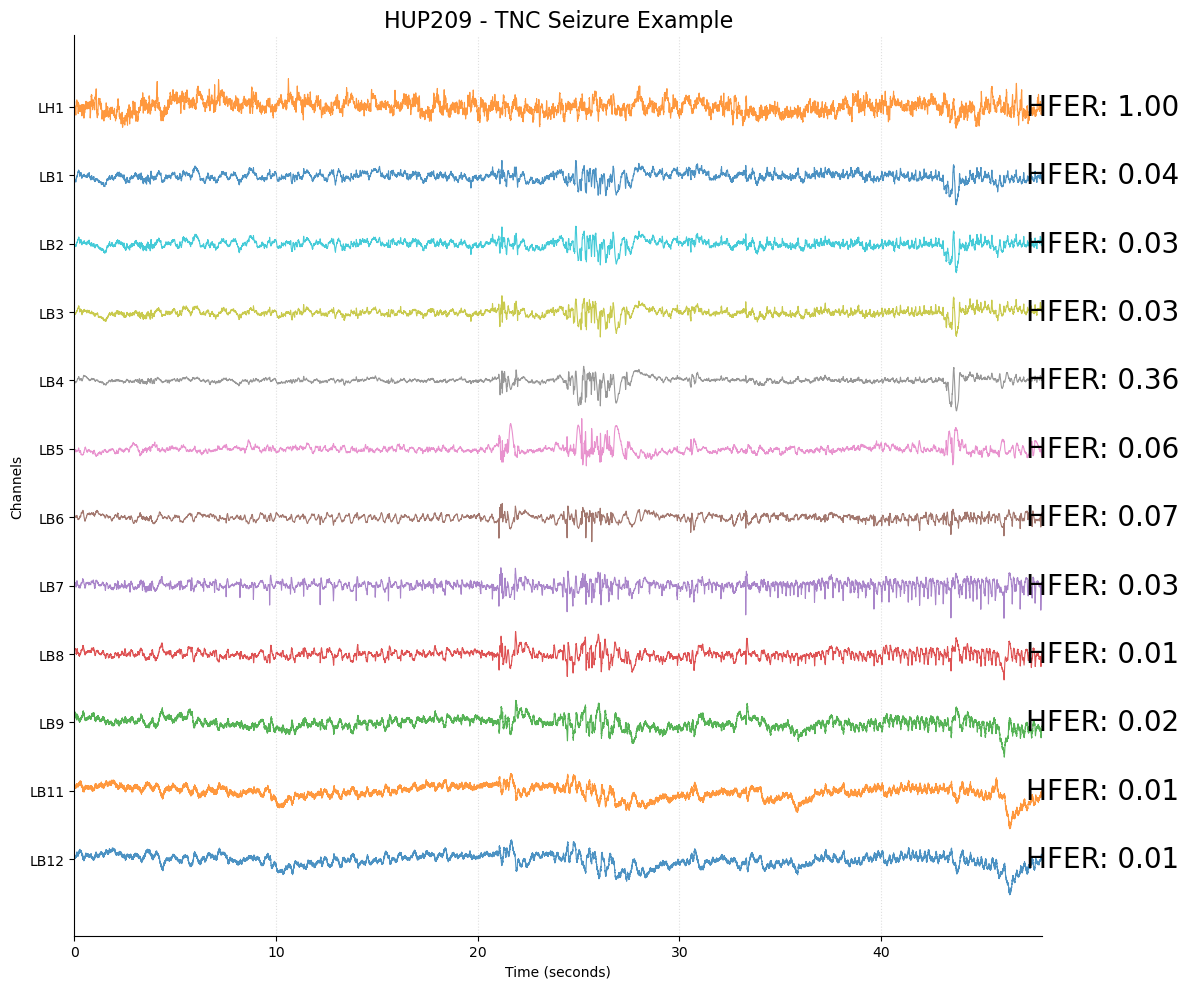

In [19]:
def plot_eeg_channels_with_hfer(data, all_spikes, sampling_rate=500, stop_time=None, title = 'Seizure Example'):
    # Create a time array
    time = np.arange(0, len(data)) / sampling_rate
    
    # Set up the plot
    plt.figure(figsize=(12, 10))
    plt.title(title, fontsize=16)
    
    # Define channel order
    sorted_la_columns = ['LA12','LA11','LA9','LA8','LA7','LA6','LA5','LA4','LA3','LA2','LA1', 'LH1']
    sorted_lb_columns = ['LB12','LB11','LB9','LB8','LB7','LB6','LB5','LB4','LB3','LB2','LB1','LH1']  

    sorted_la_columns = sorted_lb_columns
    # Calculate offset and scaling factor for better visibility
    channel_range = {ch: (data[ch].max() - data[ch].min()) for ch in sorted_la_columns}
    max_range = max(channel_range.values())
    scaling_factor = 1.5
    offset = max_range * scaling_factor * 1.2
    
    # Set x-axis limits
    if stop_time is None:
        stop_time = max(time)
    plt.xlim(0, stop_time)
    
    # Extend the x-axis to accommodate HFER values
    x_extension_factor = 1.2  # Adjust this value to move text more to the right
    plt.xlim(0, stop_time * x_extension_factor)
    
    # Plot each channel
    for i, channel in enumerate(sorted_la_columns):
        # Center and scale the data for each channel
        centered_data = data[channel] - data[channel].mean()
        scaled_data = (centered_data / channel_range[channel]) * (max_range * scaling_factor)
        
        plt.plot(time, scaled_data + i*offset, linewidth=0.8, alpha=0.8)
        
        # Add HFER value as text
        hfer_value = all_spikes[all_spikes['channel_label'] == channel]['EI'].values
        if len(hfer_value) > 0:
            hfer_text = f"HFER: {hfer_value[0]:.2f}"
            plt.text(stop_time * (x_extension_factor - 0.02), i*offset, hfer_text, 
                     verticalalignment='center', horizontalalignment='left', fontsize=20)
    
    # Set y-ticks and labels to channel names
    plt.yticks(np.arange(len(sorted_la_columns)) * offset, sorted_la_columns)
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Channels')
    
    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    # Add minor gridlines for better time reference
    plt.grid(True, which='both', axis='x', linestyle=':', alpha=0.4)
    
    plt.tight_layout()
    plt.show()



plot_eeg_channels_with_hfer(lb_data, all_spikes, stop_time=40, title = 'HUP209 - TNC Seizure Example')

In [20]:
sz_204

,hupID,rid,ictal_start_time,EI,name,removed_channels
501,HUP209,sub-RID0647,224467.79,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[LC04, LC07, LB06, LC08, LB05, LC06, LB07, LA0...",[]
502,HUP209,sub-RID0647,236351.47,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[LC04, LC07, LB06, LC08, LB05, LC06, LB07, LA0...",[]
503,HUP209,sub-RID0647,255877.78,"[0.02320564, 0.02729877, 0.07094075, 0.1765414...","[LC04, LC07, LB06, LC08, LB05, LC06, LB07, LA0...",[]
